# Cricket Score Predictor

## Table of Contents

## 1️⃣ Imports

In [7]:
# -- Data Handling --
import pandas as pd
import numpy as np

# -- Visualization --
import matplotlib.pyplot as plt
import seaborn as sns

# -- Model Development --
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -- Model Evaluation --
from sklearn.model_selection import train_test_split

## 2️⃣Data Loading

In [8]:
from google.colab import files

uploaded = files.upload()

Saving ipl.csv to ipl.csv


In [9]:
import os

print(os.listdir('/content'))

['.config', 'ipl.csv', 'sample_data']


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
df = pd.read_csv('ipl.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

First 5 rows of the DataFrame:
   mid        date                  venue               bat_team  \
0    1  2008-04-18  M Chinnaswamy Stadium  Kolkata Knight Riders   
1    1  2008-04-18  M Chinnaswamy Stadium  Kolkata Knight Riders   
2    1  2008-04-18  M Chinnaswamy Stadium  Kolkata Knight Riders   
3    1  2008-04-18  M Chinnaswamy Stadium  Kolkata Knight Riders   
4    1  2008-04-18  M Chinnaswamy Stadium  Kolkata Knight Riders   

                     bowl_team      batsman   bowler  runs  wickets  overs  \
0  Royal Challengers Bangalore   SC Ganguly  P Kumar     1        0    0.1   
1  Royal Challengers Bangalore  BB McCullum  P Kumar     1        0    0.2   
2  Royal Challengers Bangalore  BB McCullum  P Kumar     2        0    0.2   
3  Royal Challengers Bangalore  BB McCullum  P Kumar     2        0    0.3   
4  Royal Challengers Bangalore  BB McCullum  P Kumar     2        0    0.4   

   runs_last_5  wickets_last_5  striker  non-striker  total  
0            1               

In [13]:
print("\nLast 5 rows of the DataFrame:")
print(df.tail())


Last 5 rows of the DataFrame:
       mid        date                                      venue  \
76009  617  2017-05-21  Rajiv Gandhi International Stadium, Uppal   
76010  617  2017-05-21  Rajiv Gandhi International Stadium, Uppal   
76011  617  2017-05-21  Rajiv Gandhi International Stadium, Uppal   
76012  617  2017-05-21  Rajiv Gandhi International Stadium, Uppal   
76013  617  2017-05-21  Rajiv Gandhi International Stadium, Uppal   

             bat_team               bowl_team     batsman        bowler  runs  \
76009  Mumbai Indians  Rising Pune Supergiant   KH Pandya  DT Christian   121   
76010  Mumbai Indians  Rising Pune Supergiant   KH Pandya  DT Christian   127   
76011  Mumbai Indians  Rising Pune Supergiant   KH Pandya  DT Christian   128   
76012  Mumbai Indians  Rising Pune Supergiant  MG Johnson  DT Christian   129   
76013  Mumbai Indians  Rising Pune Supergiant   KH Pandya  DT Christian   129   

       wickets  overs  runs_last_5  wickets_last_5  striker  non-st

## 3️⃣Basic Data Inspection

In [14]:
# -- Shape --
print(df.shape)

(76014, 15)


In [15]:
# -- Columns & their Data Types--
print("Column Names & Data Types :")
print(df.dtypes)

Column Names & Data Types :
mid                 int64
date               object
venue              object
bat_team           object
bowl_team          object
batsman            object
bowler             object
runs                int64
wickets             int64
overs             float64
runs_last_5         int64
wickets_last_5      int64
striker             int64
non-striker         int64
total               int64
dtype: object


In [16]:
# -- Info --
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB
None


In [17]:
# -- Missing values --
print("Missing Values Record: ")
print(df.isnull().sum())

Missing Values Record: 
mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64


In [18]:
# -- Statistics --
print("\nSummary statistics of the DataFrame:")
print(df.describe())


Summary statistics of the DataFrame:
                mid          runs       wickets         overs   runs_last_5  \
count  76014.000000  76014.000000  76014.000000  76014.000000  76014.000000   
mean     308.627740     74.889349      2.415844      9.783068     33.216434   
std      178.156878     48.823327      2.015207      5.772587     14.914174   
min        1.000000      0.000000      0.000000      0.000000      0.000000   
25%      154.000000     34.000000      1.000000      4.600000     24.000000   
50%      308.000000     70.000000      2.000000      9.600000     34.000000   
75%      463.000000    111.000000      4.000000     14.600000     43.000000   
max      617.000000    263.000000     10.000000     19.600000    113.000000   

       wickets_last_5       striker   non-striker         total  
count    76014.000000  76014.000000  76014.000000  76014.000000  
mean         1.120307     24.962283      8.869287    160.901452  
std          1.053343     20.079752     10.795742   

## 4️⃣ DataSet Information

#### It tells the following information about the Dataset:
- Team Names
- Venue Names

### Team Names

In [19]:
print(f"Batting Team:\n{df['bat_team'].unique()}\n")
print(f"Bowling Team:\n{df['bowl_team'].unique()}")

Batting Team:
['Kolkata Knight Riders' 'Chennai Super Kings' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Kings XI Punjab'
 'Royal Challengers Bangalore' 'Delhi Daredevils' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Rising Pune Supergiant']

Bowling Team:
['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Kolkata Knight Riders' 'Rajasthan Royals' 'Mumbai Indians'
 'Chennai Super Kings' 'Deccan Chargers' 'Pune Warriors'
 'Kochi Tuskers Kerala' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Rising Pune Supergiant']


### Venue Names

In [20]:
print(df['venue'].value_counts())

venue
M Chinnaswamy Stadium                                   7443
Feroz Shah Kotla                                        7068
Eden Gardens                                            7049
Wankhede Stadium                                        7048
MA Chidambaram Stadium, Chepauk                         5972
Rajiv Gandhi International Stadium, Uppal               5827
Punjab Cricket Association Stadium, Mohali              4247
Sawai Mansingh Stadium                                  4110
Dr DY Patil Sports Academy                              2088
Subrata Roy Sahara Stadium                              2086
Maharashtra Cricket Association Stadium                 1843
Kingsmead                                               1731
Sardar Patel Stadium, Motera                            1484
Brabourne Stadium                                       1380
SuperSport Park                                         1377
Punjab Cricket Association IS Bindra Stadium, Mohali    1342
Saurashtra Cricket

## 5️⃣ Exploratory Data Analysis(EDA)

### 5.1 Target Variable Distribution

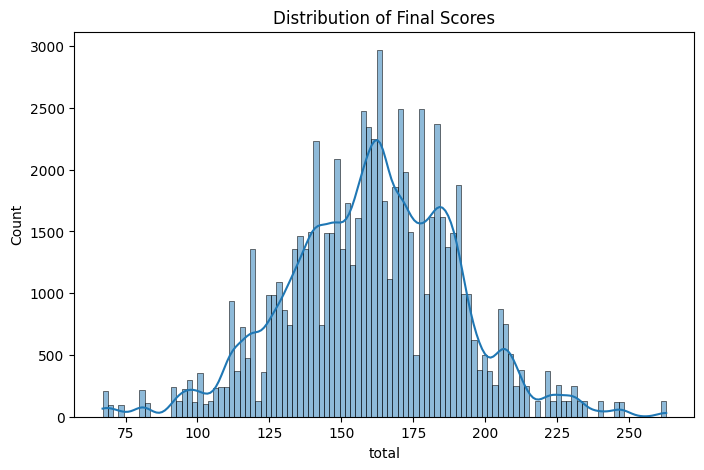

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['total'], kde=True)
plt.title("Distribution of Final Scores")
plt.show()

##### The distribution of final scores is approximately bell-shaped and centered around 160–180 runs. Most IPL first-innings scores fall within this range, while very low (<100) and very high (>220) scores are relatively rare. This indicates that the dataset is reasonably balanced and suitable for score prediction.

### 5.2 Correlation Heatmap

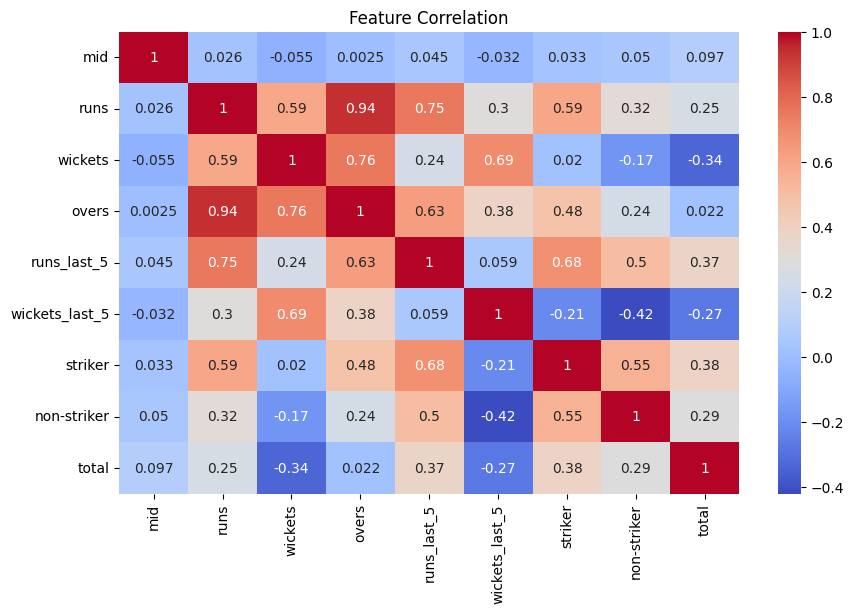

In [22]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation")
plt.show()

##### The correlation heatmap shows that striker (0.38), runs_last_5 (0.37), and non-striker (0.29) have the strongest positive relationship with the final score. On the other hand, wickets (-0.34) and wickets_last_5 (-0.27) show a negative correlation, indicating that losing more wickets generally reduces the final innings total.

### 5.3 Runs vs Total Score

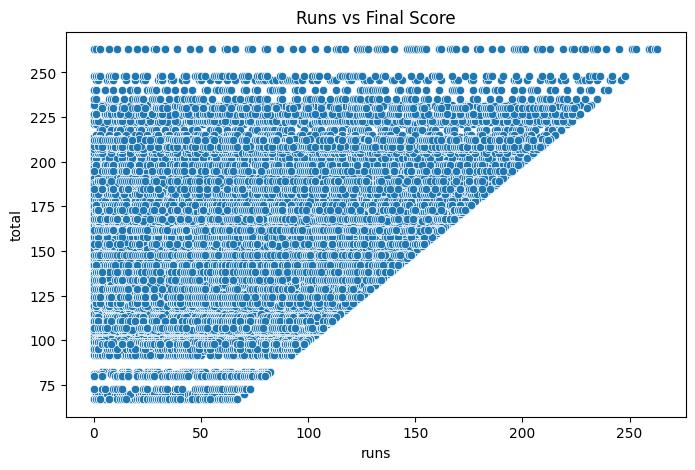

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='runs',
    y='total',
    data=df
)
plt.title("Runs vs Final Score")
plt.show()

##### The scatter plot shows a positive relationship between current runs and the final innings score. As the team's current score increases, the predicted final score also tends to increase. This indicates that the current runs scored are an important factor in determining the final total.

### 5.4 Wickets vs Total Score





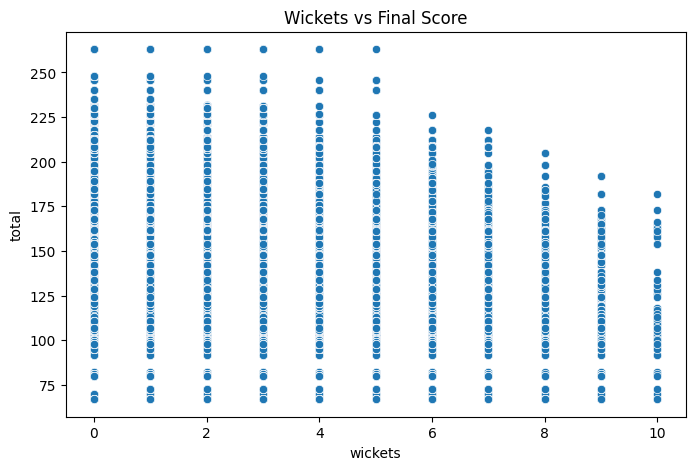

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='wickets',
    y='total',
    data=df
)
plt.title("Wickets vs Final Score")
plt.show()

##### The scatter plot indicates a negative relationship between wickets lost and the final innings score. Teams that lose fewer wickets generally achieve higher totals, while teams losing more wickets tend to score fewer runs.

### 5.5 Top Venues




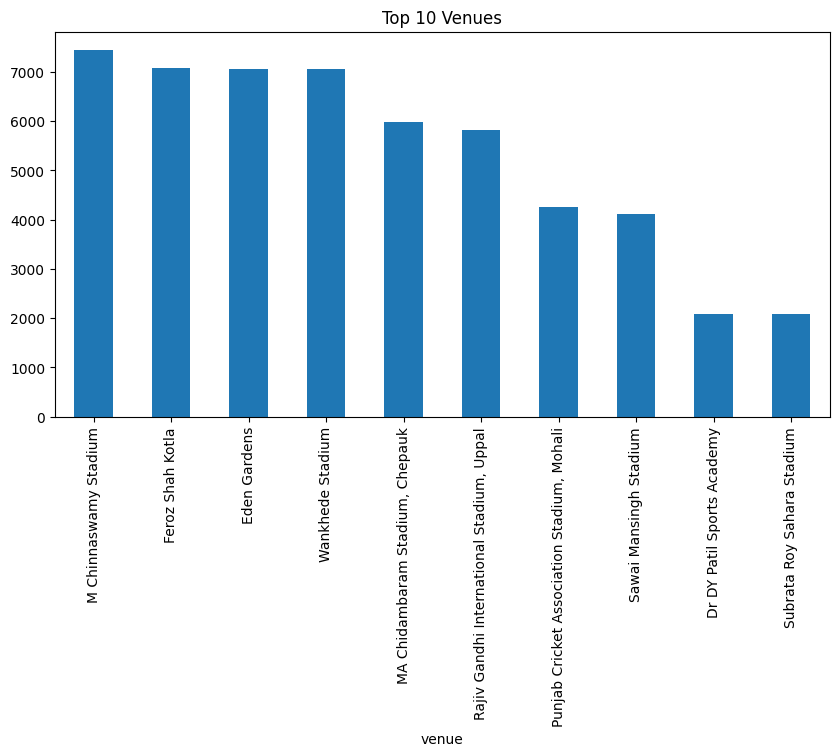

In [25]:
plt.figure(figsize=(10,5))
df['venue'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Venues")
plt.show()

### 5.6 Most Frequent Batting Teams

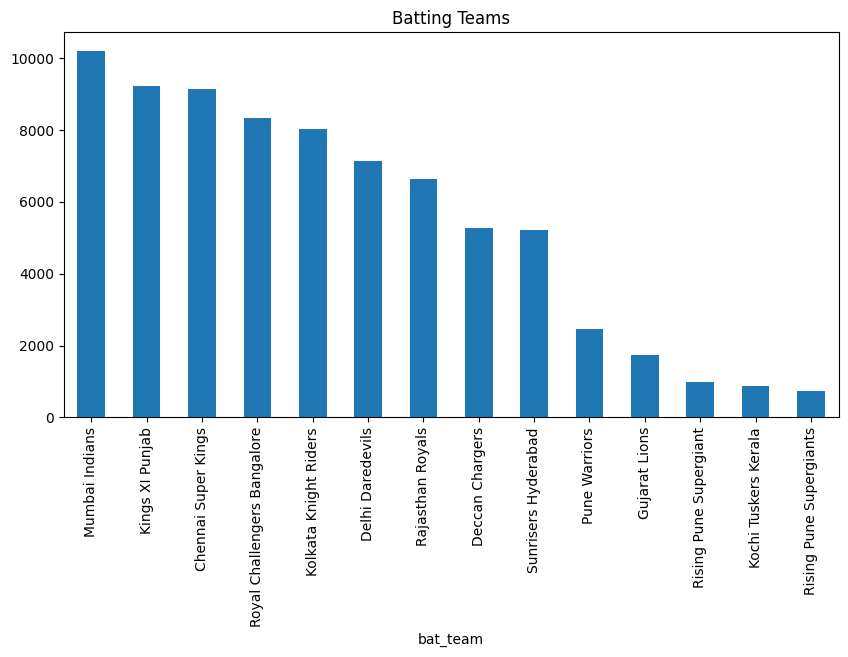

In [26]:
plt.figure(figsize=(10,5))
df['bat_team'].value_counts().plot(kind='bar')
plt.title("Batting Teams")
plt.show()

## 6️⃣ Data Pre-Processing

### 6.1 Missing Values Check

In [27]:
df.isnull().sum()

,0
mid,0
date,0
venue,0
bat_team,0
bowl_team,0
batsman,0
bowler,0
runs,0
wickets,0
overs,0


### 6.2 Filter Invalid Cricket Data

##### To check that data has recorded
- 20 overs or less in the match
- 10 wickets or less in the match

#### Checking Overs

In [28]:
df = df[df['overs'] <= 20]

#### Checking Wickets

In [29]:
df = df[df['wickets'] <= 10]

### 6.3 Feature Selection

##### For IPL Score Prediction

In [30]:
X = df[
    [
        'venue',
        'bat_team',
        'bowl_team',
        'runs',
        'wickets',
        'overs',
        'runs_last_5',
        'wickets_last_5'
    ]
]

y = df['total']

### 6.4 Categorical Encoding

##### We will use One Hot Encoding here.

In [31]:
categorical_cols = [
    'venue',
    'bat_team',
    'bowl_team'
]

#### Column Transformer

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

### 6.5 Outlier Detection

#### Score Distribution

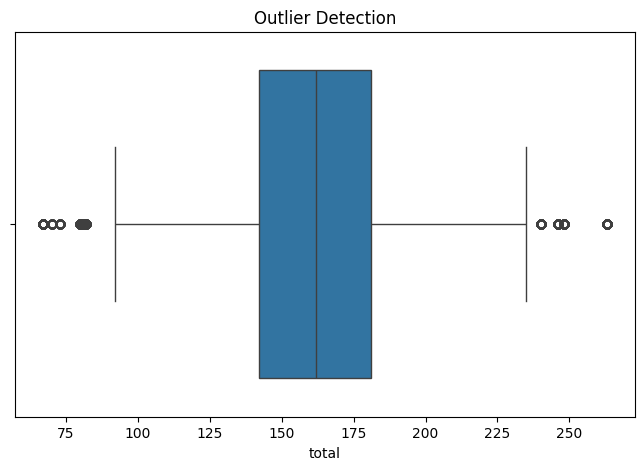

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['total'])
plt.title("Outlier Detection")
plt.show()

##### The box plot shows that the median IPL first-innings score is around 162 runs. Most scores lie between 142 and 181 runs, indicating a stable scoring pattern. A small number of outliers are present below 92 runs and above 235 runs, representing unusually low and high-scoring innings.

## 7️⃣ Train-Test Split

### 7.1 Defining Features

##### X *Features*

In [34]:
X = df[
    [
        'bat_team',
        'bowl_team',
        'venue',
        'runs',
        'wickets',
        'overs',
        'runs_last_5',
        'wickets_last_5'
    ]
]

##### Y Features (Target)

In [35]:
y = df['total']

### 7.2 Splitting the Data

##### 80% Training & 20% Testing

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##### Verify Shapes

In [37]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (60811, 8)
X_test : (15203, 8)
y_train: (60811,)
y_test : (15203,)


### 7.3 Encoding

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    'venue',
    'bat_team',
    'bowl_team'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

### 7.4 Linear Regression Model

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

## 8️⃣ Linear Regression Model

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

### 8.2 Training

In [41]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['venue', 'bat_team',
                                                   'bowl_team'])])),
                ('regressor', LinearRegression())])

### 8.3 Prediction

In [42]:
y_pred = model.predict(X_test)

### 8.4 Evaluation

In [43]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

### 8.5 MAE, RMSE, R² Score



In [44]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

MAE: 14.414349251565325
RMSE: 19.366051247209793
R² Score: 0.555367269349859


## 9️⃣ Prediction from User Input

In [49]:
sample = pd.DataFrame({
    'venue': ['M Chinnaswamy Stadium'],
    'bat_team': ['Royal Challengers Bangalore'],
    'bowl_team': ['Mumbai Indians'],
    'runs': [165],
    'wickets': [8],
    'overs': [12],
    'runs_last_5': [49],
    'wickets_last_5': [0],
    'striker': [68],
    'non-striker': [56]
})

prediction = model.predict(sample)

print("Predicted Final Score:", round(prediction[0]))

Predicted Final Score: 209


## 1️⃣0️⃣ Save Model

In [50]:
import pickle

with open('cricket_score_predictor.pkl', 'wb') as file:
    pickle.dump(model, file)